In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

import re
import nltk
import pymorphy3

import gensim

import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [2]:
df1 = pd.read_csv('MyHabr.csv')
df2 = pd.read_csv('PDF_10_Habr.csv')

df_combined = pd.concat([df1, df2], ignore_index=True)

df_combined.to_csv('All_Habr.csv', index=False)

In [3]:
df = pd.read_csv('All_Habr.csv')

In [4]:
df.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub
0,0,Как граф транзакций помогает банку лучше узнат...,Сбер,"Технологии, меняющие мир","531,62","Блог компании Сбер, Машинное обучение",2026-04-13,"Привет, Хабр.\r\nКаждый раз, когда вы платите ..."
1,1,"Пилот WAF: как подготовиться, чтобы не упасть ...",WMX,ИБ-вендор решений для защиты веб-приложений и API,"27,28","Блог компании WMX, Информационная безопасность",2026-04-13,"Никто не хочет покупать кота в мешке, особенно..."
2,2,"Как строить ИБ, когда у атакующего может быть ...",Ideco,NaN,"68,03","Блог компании Ideco, Информационная безопаснос...",2026-04-13,"Anthropic выпустила модель, которая за несколь..."
3,3,"«Увидеть» сигнал, «нарисовать» комнату, постро...",VAS Experts,Разработчик платформы глубокого анализа трафика,"65,7","Блог компании VAS Experts, Исследования и прог...",2026-04-12,"Сегодня мы рассмотрим несколько исследований, ..."
4,4,Серверные FHE-ускорители для шифрования,GlobalSign,NaN,"140,01","Блог компании GlobalSign, Информационная безоп...",2026-04-12,Прототип микросхемы Intel Heracles\r\nЗащита к...


In [5]:
df['textpub'][0]

'Привет, Хабр.\r\nКаждый раз, когда вы платите картой, банк записывает это событие. Со временем накапливается история: купил кофе — запись, оплатил газ — запись, снял наличные — запись. Банковский ИИ умеет анализировать последовательность событий и делать выводы о человеке: молодой или пожилой, семьянин или одиночка, предпочитает копить или тратить.\r\nНо у этого подхода есть недостаток: ИИ-модель рассматривает каждого клиента изолированно, как будто он один на всём белом свете. Однако если посмотреть на\xa0всех клиентов и все магазины сразу, то образуется огромная сеть связей: клиент ↔ магазин ↔ другие клиенты, которые ходят в\xa0тот\xa0же магазин. В\xa0науке такую структуру называют двудольным графом.\r\nВ\xa0нашей совместной работе с\xa0коллегами из\xa0AIRI, ИСП РАН и Математического института имени Стеклова мы показали, что двудольный граф содержит помимо истории платежей множество другой полезной информации. И мы научились добавлять её в\xa0существующие модели без\xa0их переписыва

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   185 non-null    int64 
 1   title        185 non-null    object
 2   namecompany  185 non-null    object
 3   description  136 non-null    object
 4   rating       185 non-null    object
 5   field        185 non-null    object
 6   date         185 non-null    object
 7   textpub      185 non-null    object
dtypes: int64(1), object(7)
memory usage: 11.7+ KB


In [7]:
df['corpus'] = (df['title'].fillna('') + ' ' + 
                df['textpub'].fillna(''))

### Предобработка текста

In [8]:
st = '\xa0—'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [9]:
df['prep_text']= [remove_othersymbol(text.lower()) for text in df['corpus']]

In [10]:
df['prep_text'][0]

'как граф транзакций помогает банку лучше узнать своего клиента привет, хабр.\r\nкаждый раз, когда вы платите картой, банк записывает это событие. со временем накапливается история: купил кофе   запись, оплатил газ   запись, снял наличные   запись. банковский ии умеет анализировать последовательность событий и делать выводы о человеке: молодой или пожилой, семьянин или одиночка, предпочитает копить или тратить.\r\nно у этого подхода есть недостаток: ии-модель рассматривает каждого клиента изолированно, как будто он один на всём белом свете. однако если посмотреть на всех клиентов и все магазины сразу, то образуется огромная сеть связей: клиент ↔ магазин ↔ другие клиенты, которые ходят в тот же магазин. в науке такую структуру называют двудольным графом.\r\nв нашей совместной работе с коллегами из airi, исп ран и математического института имени стеклова мы показали, что двудольный граф содержит помимо истории платежей множество другой полезной информации. и мы научились добавлять её в с

In [11]:
def remove_punctuation(text):
    return ''.join([ch for ch in text if ch not in string.punctuation])

In [12]:
df['prep_text']= [remove_punctuation(text) for text in df['prep_text']]

In [13]:
df['prep_text'][0]

'как граф транзакций помогает банку лучше узнать своего клиента привет хабр\r\nкаждый раз когда вы платите картой банк записывает это событие со временем накапливается история купил кофе   запись оплатил газ   запись снял наличные   запись банковский ии умеет анализировать последовательность событий и делать выводы о человеке молодой или пожилой семьянин или одиночка предпочитает копить или тратить\r\nно у этого подхода есть недостаток иимодель рассматривает каждого клиента изолированно как будто он один на всём белом свете однако если посмотреть на всех клиентов и все магазины сразу то образуется огромная сеть связей клиент ↔ магазин ↔ другие клиенты которые ходят в тот же магазин в науке такую структуру называют двудольным графом\r\nв нашей совместной работе с коллегами из airi исп ран и математического института имени стеклова мы показали что двудольный граф содержит помимо истории платежей множество другой полезной информации и мы научились добавлять её в существующие модели без их

In [14]:
df.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub,corpus,prep_text
0,0,Как граф транзакций помогает банку лучше узнат...,Сбер,"Технологии, меняющие мир","531,62","Блог компании Сбер, Машинное обучение",2026-04-13,"Привет, Хабр.\r\nКаждый раз, когда вы платите ...",Как граф транзакций помогает банку лучше узнат...,как граф транзакций помогает банку лучше узнат...
1,1,"Пилот WAF: как подготовиться, чтобы не упасть ...",WMX,ИБ-вендор решений для защиты веб-приложений и API,"27,28","Блог компании WMX, Информационная безопасность",2026-04-13,"Никто не хочет покупать кота в мешке, особенно...","Пилот WAF: как подготовиться, чтобы не упасть ...",пилот waf как подготовиться чтобы не упасть в ...
2,2,"Как строить ИБ, когда у атакующего может быть ...",Ideco,NaN,"68,03","Блог компании Ideco, Информационная безопаснос...",2026-04-13,"Anthropic выпустила модель, которая за несколь...","Как строить ИБ, когда у атакующего может быть ...",как строить иб когда у атакующего может быть a...
3,3,"«Увидеть» сигнал, «нарисовать» комнату, постро...",VAS Experts,Разработчик платформы глубокого анализа трафика,"65,7","Блог компании VAS Experts, Исследования и прог...",2026-04-12,"Сегодня мы рассмотрим несколько исследований, ...","«Увидеть» сигнал, «нарисовать» комнату, постро...",«увидеть» сигнал «нарисовать» комнату построит...
4,4,Серверные FHE-ускорители для шифрования,GlobalSign,NaN,"140,01","Блог компании GlobalSign, Информационная безоп...",2026-04-12,Прототип микросхемы Intel Heracles\r\nЗащита к...,Серверные FHE-ускорители для шифрования Протот...,серверные fheускорители для шифрования прототи...


In [15]:
import nltk
nltk.download('stopwords')
russian_stopwords = stopwords.words("russian") 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Adil1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный','фильм', 'кино', 'смотреть', 'год', 'снят', 'рассказывает', 'история', 
                'оказывается', 'вдруг', 'наконец', 'также', 'который', 'который', 'этот', 'эта', 'это', 'эти', 'подписаться', 'каждый', 'просто', 'очень', 'назад', 
                'час назад', 'простой', 'март', 'привет хабр', 'то есть', 'подписаться', 'каждый', 'просто', 'очень', 'назад', 'час назад', 
                'простой', 'март', 'хороший', 'несколько', 'нужно', 'прямо', 'вместе', 'общий', 'разный', 'особый', 'целое', 'часть', 'результат', 'слово', 'порядок', 'подход', 'ответ', 
                'параметр', 'делегировать', 'требоваться', 'использование', 'час', 'день', 'понедельник', 'вторник', 'среда', 'четверг', 'пятница', 'суббота', 'воскресенье', 'число', 'сутки',
                'сегодняшний', 'банально', 'например', 'ия']) 

In [17]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Adil1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [18]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [19]:
%%time
lemm_texts_list = []
for text in (df['prep_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['text_lemm'] = lemm_texts_list

CPU times: total: 38 s
Wall time: 38 s


In [20]:
df.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm
0,0,Как граф транзакций помогает банку лучше узнат...,Сбер,"Технологии, меняющие мир","531,62","Блог компании Сбер, Машинное обучение",2026-04-13,"Привет, Хабр.\r\nКаждый раз, когда вы платите ...",Как граф транзакций помогает банку лучше узнат...,как граф транзакций помогает банку лучше узнат...,как граф транзакция помогать банк хороший узна...
1,1,"Пилот WAF: как подготовиться, чтобы не упасть ...",WMX,ИБ-вендор решений для защиты веб-приложений и API,"27,28","Блог компании WMX, Информационная безопасность",2026-04-13,"Никто не хочет покупать кота в мешке, особенно...","Пилот WAF: как подготовиться, чтобы не упасть ...",пилот waf как подготовиться чтобы не упасть в ...,пилот waf как подготовиться чтобы не упасть в ...
2,2,"Как строить ИБ, когда у атакующего может быть ...",Ideco,NaN,"68,03","Блог компании Ideco, Информационная безопаснос...",2026-04-13,"Anthropic выпустила модель, которая за несколь...","Как строить ИБ, когда у атакующего может быть ...",как строить иб когда у атакующего может быть a...,как строить иб когда у атаковать мочь быть ai ...
3,3,"«Увидеть» сигнал, «нарисовать» комнату, постро...",VAS Experts,Разработчик платформы глубокого анализа трафика,"65,7","Блог компании VAS Experts, Исследования и прог...",2026-04-12,"Сегодня мы рассмотрим несколько исследований, ...","«Увидеть» сигнал, «нарисовать» комнату, постро...",«увидеть» сигнал «нарисовать» комнату построит...,« увидеть » сигнал « нарисовать » комната пост...
4,4,Серверные FHE-ускорители для шифрования,GlobalSign,NaN,"140,01","Блог компании GlobalSign, Информационная безоп...",2026-04-12,Прототип микросхемы Intel Heracles\r\nЗащита к...,Серверные FHE-ускорители для шифрования Протот...,серверные fheускорители для шифрования прототи...,серверный fheускоритель для шифрование прототи...


In [21]:
df['text_lemm'][0]

'как граф транзакция помогать банк хороший узнать свой клиент привет хабра каждый раз когда вы платить карта банк записывать это событие с время накапливаться история купить кофе запись оплатить газ запись снять наличный запись банковский ия уметь анализировать последовательность событие и делать вывод о человек молодой или пожилой семьянин или одиночка предпочитать копить или тратить но у это подход есть недостаток иимодель рассматривать каждый клиент изолированно как будто он один на весь белый свет однако если посмотреть на весь клиент и всё магазин сразу то образоваться огромный сеть связь клиент ↔ магазин ↔ другой клиент который ходить в тот же магазин в наука такой структура называть двудольный граф в наш совместный работа с коллега из airi исп ран и математический институт имя стеклов мы показать что двудольный граф содержать помимо история платёж множество другой полезный информация и мы научиться добавлять её в существующий модель без они переписывание с нуль слабый место стан

In [22]:
def clean_textpub(text):
    text = re.sub(r'\b\w*\d\w*\b', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    
    return text

In [23]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords and len(t) > 2]
    text = " ".join(tokens)
    return clean_textpub(text)

In [24]:
df['tokenize_text'] = [tokenize(text) for text in df['text_lemm']]

In [25]:
df.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm,tokenize_text
0,0,Как граф транзакций помогает банку лучше узнат...,Сбер,"Технологии, меняющие мир","531,62","Блог компании Сбер, Машинное обучение",2026-04-13,"Привет, Хабр.\r\nКаждый раз, когда вы платите ...",Как граф транзакций помогает банку лучше узнат...,как граф транзакций помогает банку лучше узнат...,как граф транзакция помогать банк хороший узна...,граф транзакция помогать банк узнать клиент пр...
1,1,"Пилот WAF: как подготовиться, чтобы не упасть ...",WMX,ИБ-вендор решений для защиты веб-приложений и API,"27,28","Блог компании WMX, Информационная безопасность",2026-04-13,"Никто не хочет покупать кота в мешке, особенно...","Пилот WAF: как подготовиться, чтобы не упасть ...",пилот waf как подготовиться чтобы не упасть в ...,пилот waf как подготовиться чтобы не упасть в ...,пилот waf подготовиться упасть прод затянуть с...
2,2,"Как строить ИБ, когда у атакующего может быть ...",Ideco,NaN,"68,03","Блог компании Ideco, Информационная безопаснос...",2026-04-13,"Anthropic выпустила модель, которая за несколь...","Как строить ИБ, когда у атакующего может быть ...",как строить иб когда у атакующего может быть a...,как строить иб когда у атаковать мочь быть ai ...,строить иб атаковать мочь ai уровень mythos an...
3,3,"«Увидеть» сигнал, «нарисовать» комнату, постро...",VAS Experts,Разработчик платформы глубокого анализа трафика,"65,7","Блог компании VAS Experts, Исследования и прог...",2026-04-12,"Сегодня мы рассмотрим несколько исследований, ...","«Увидеть» сигнал, «нарисовать» комнату, постро...",«увидеть» сигнал «нарисовать» комнату построит...,« увидеть » сигнал « нарисовать » комната пост...,увидеть сигнал нарисовать комната пост...
4,4,Серверные FHE-ускорители для шифрования,GlobalSign,NaN,"140,01","Блог компании GlobalSign, Информационная безоп...",2026-04-12,Прототип микросхемы Intel Heracles\r\nЗащита к...,Серверные FHE-ускорители для шифрования Протот...,серверные fheускорители для шифрования прототи...,серверный fheускоритель для шифрование прототи...,серверный fheускоритель шифрование прототип ми...


In [26]:
df['tokenize_text'][0]

'граф транзакция помогать банк узнать клиент привет хабра платить карта банк записывать событие время накапливаться купить кофе запись оплатить газ запись снять наличный запись банковский уметь анализировать последовательность событие делать вывод человек молодой пожилой семьянин одиночка предпочитать копить тратить недостаток иимодель рассматривать клиент изолированно весь белый свет однако посмотреть весь клиент магазин сразу образоваться огромный сеть связь клиент   магазин   клиент ходить магазин наука структура называть двудольный граф наш совместный работа коллега airi исп ран математический институт имя стеклов показать двудольный граф содержать помимо платёж множество полезный информация научиться добавлять существующий модель переписывание нуль слабый место стандартный современный метод самообучение selfsupervised learning отлично работать последовательность событие модель анализировать клиент учиться предсказывать пропустить операция сравнивать отрезок биография процесс работ

In [27]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

<Axes: >

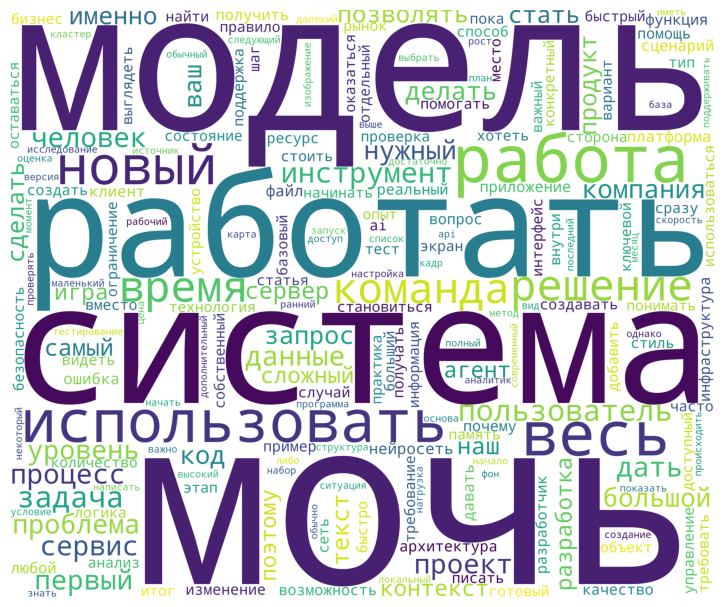

In [29]:
corpus = get_corpus(df['tokenize_text'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [30]:
def get_wordCloud2(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(corpus)
    return wordCloud

<Axes: >

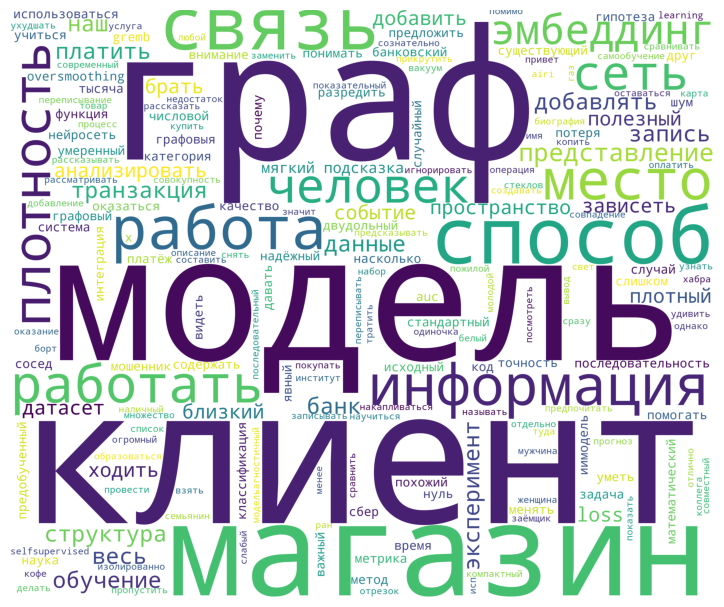

In [31]:
corpus = df['tokenize_text'][0]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

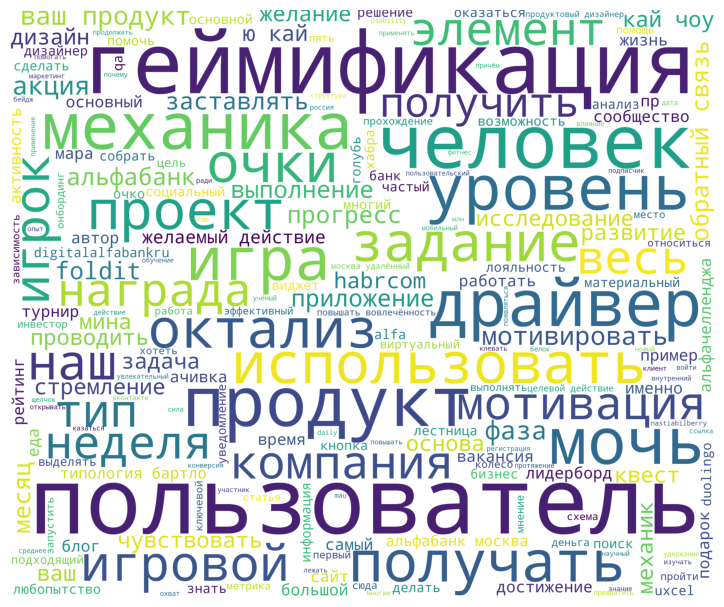

In [32]:
corpus = df['tokenize_text'][len(df)-1]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

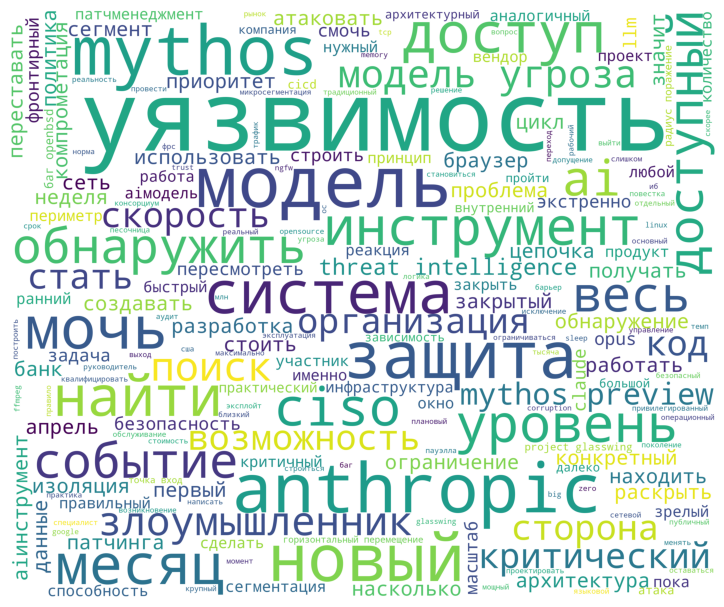

In [33]:
corpus = df['tokenize_text'][2]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [34]:
df.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm,tokenize_text
0,0,Как граф транзакций помогает банку лучше узнат...,Сбер,"Технологии, меняющие мир","531,62","Блог компании Сбер, Машинное обучение",2026-04-13,"Привет, Хабр.\r\nКаждый раз, когда вы платите ...",Как граф транзакций помогает банку лучше узнат...,как граф транзакций помогает банку лучше узнат...,как граф транзакция помогать банк хороший узна...,граф транзакция помогать банк узнать клиент пр...
1,1,"Пилот WAF: как подготовиться, чтобы не упасть ...",WMX,ИБ-вендор решений для защиты веб-приложений и API,"27,28","Блог компании WMX, Информационная безопасность",2026-04-13,"Никто не хочет покупать кота в мешке, особенно...","Пилот WAF: как подготовиться, чтобы не упасть ...",пилот waf как подготовиться чтобы не упасть в ...,пилот waf как подготовиться чтобы не упасть в ...,пилот waf подготовиться упасть прод затянуть с...
2,2,"Как строить ИБ, когда у атакующего может быть ...",Ideco,NaN,"68,03","Блог компании Ideco, Информационная безопаснос...",2026-04-13,"Anthropic выпустила модель, которая за несколь...","Как строить ИБ, когда у атакующего может быть ...",как строить иб когда у атакующего может быть a...,как строить иб когда у атаковать мочь быть ai ...,строить иб атаковать мочь ai уровень mythos an...
3,3,"«Увидеть» сигнал, «нарисовать» комнату, постро...",VAS Experts,Разработчик платформы глубокого анализа трафика,"65,7","Блог компании VAS Experts, Исследования и прог...",2026-04-12,"Сегодня мы рассмотрим несколько исследований, ...","«Увидеть» сигнал, «нарисовать» комнату, постро...",«увидеть» сигнал «нарисовать» комнату построит...,« увидеть » сигнал « нарисовать » комната пост...,увидеть сигнал нарисовать комната пост...
4,4,Серверные FHE-ускорители для шифрования,GlobalSign,NaN,"140,01","Блог компании GlobalSign, Информационная безоп...",2026-04-12,Прототип микросхемы Intel Heracles\r\nЗащита к...,Серверные FHE-ускорители для шифрования Протот...,серверные fheускорители для шифрования прототи...,серверный fheускоритель для шифрование прототи...,серверный fheускоритель шифрование прототип ми...


# Векторизация текстовых данных

### Bag of words

In [35]:
count_vec = CountVectorizer(max_df=0.7, min_df=3, max_features=5000, ngram_range=(1, 3), analyzer='word')
count_matrix = count_vec.fit_transform(df['tokenize_text'])

feature_names = count_vec.get_feature_names_out()

In [36]:
len(count_vec.vocabulary_)

5000

In [37]:
count_matrix.shape

(185, 5000)

In [38]:
feature_names

array(['acp', 'acp вайбкодим', 'acp вайбкодим тг', ..., 'ясный', 'ящик',
       'ёмкость'], shape=(5000,), dtype=object)

### TF-IDF

In [39]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.7,         
    min_df=3,            
    max_features=5000,   
    ngram_range=(1, 3),  
    analyzer='word'
)

In [40]:
tfidf_matrix = tfidf_vectorizer.fit_transform(df['tokenize_text'])

In [41]:
tfidf_matrix.shape

(185, 5000)

In [42]:
print(tfidf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 73566 stored elements and shape (185, 5000)>
  Coords	Values
  (0, 1183)	0.5195033712451561
  (0, 4494)	0.12795815797319526
  (0, 3190)	0.030509748196160067
  (0, 648)	0.09968072288702506
  (0, 4585)	0.01976774900038
  (0, 1832)	0.3238239278185882
  (0, 3378)	0.019014449477378324
  (0, 4794)	0.019195991778832446
  (0, 2996)	0.11297501423178188
  (0, 1787)	0.01570883984332802
  (0, 1506)	0.029532607867668818
  (0, 4111)	0.05599109562052797
  (0, 2341)	0.030267944188531595
  (0, 2012)	0.023198585416989045
  (0, 1507)	0.08330512789043687
  (0, 2682)	0.031989539493298816
  (0, 1095)	0.031989539493298816
  (0, 4101)	0.031989539493298816
  (0, 649)	0.059065215735337635
  (0, 4608)	0.03570164390042743
  (0, 591)	0.06616048981677812
  (0, 3236)	0.05534399267279583
  (0, 1237)	0.010905904454413811
  (0, 1015)	0.01683991377015596
  (0, 4864)	0.06490219546445135
  :	:
  (184, 1958)	0.016992287713834885
  (184, 691)	0.016992287713834885

In [43]:
tfidf_vectorizer.get_feature_names_out()[1165:1175]

array(['город', 'городской', 'горячий', 'государственный', 'государство',
       'готовить', 'готовиться', 'готовность', 'готовый',
       'готовый решение'], dtype=object)

# Тематическое моделирование

In [44]:
import gensim

In [45]:
def tokenize2(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    return tokens

In [46]:
df['tokenize_text3'] = [tokenize2(text) for text in df['tokenize_text']]

In [47]:
gensim_dictionary = gensim.corpora.Dictionary(df['tokenize_text3'])
gensim_dictionary.filter_extremes(no_above=0.1, no_below=15)
gensim_dictionary.compactify()

In [48]:
corpus = [gensim_dictionary.doc2bow(text) 
          for text in df['tokenize_text3']]

In [49]:
df.head()

,Unnamed: 0,title,namecompany,description,rating,field,date,textpub,corpus,prep_text,text_lemm,tokenize_text,tokenize_text3
0,0,Как граф транзакций помогает банку лучше узнат...,Сбер,"Технологии, меняющие мир","531,62","Блог компании Сбер, Машинное обучение",2026-04-13,"Привет, Хабр.\r\nКаждый раз, когда вы платите ...",Как граф транзакций помогает банку лучше узнат...,как граф транзакций помогает банку лучше узнат...,как граф транзакция помогать банк хороший узна...,граф транзакция помогать банк узнать клиент пр...,"[граф, транзакция, помогать, банк, узнать, кли..."
1,1,"Пилот WAF: как подготовиться, чтобы не упасть ...",WMX,ИБ-вендор решений для защиты веб-приложений и API,"27,28","Блог компании WMX, Информационная безопасность",2026-04-13,"Никто не хочет покупать кота в мешке, особенно...","Пилот WAF: как подготовиться, чтобы не упасть ...",пилот waf как подготовиться чтобы не упасть в ...,пилот waf как подготовиться чтобы не упасть в ...,пилот waf подготовиться упасть прод затянуть с...,"[пилот, waf, подготовиться, упасть, прод, затя..."
2,2,"Как строить ИБ, когда у атакующего может быть ...",Ideco,NaN,"68,03","Блог компании Ideco, Информационная безопаснос...",2026-04-13,"Anthropic выпустила модель, которая за несколь...","Как строить ИБ, когда у атакующего может быть ...",как строить иб когда у атакующего может быть a...,как строить иб когда у атаковать мочь быть ai ...,строить иб атаковать мочь ai уровень mythos an...,"[строить, иб, атаковать, мочь, ai, уровень, my..."
3,3,"«Увидеть» сигнал, «нарисовать» комнату, постро...",VAS Experts,Разработчик платформы глубокого анализа трафика,"65,7","Блог компании VAS Experts, Исследования и прог...",2026-04-12,"Сегодня мы рассмотрим несколько исследований, ...","«Увидеть» сигнал, «нарисовать» комнату, постро...",«увидеть» сигнал «нарисовать» комнату построит...,« увидеть » сигнал « нарисовать » комната пост...,увидеть сигнал нарисовать комната пост...,"[увидеть, сигнал, нарисовать, комната, построи..."
4,4,Серверные FHE-ускорители для шифрования,GlobalSign,NaN,"140,01","Блог компании GlobalSign, Информационная безоп...",2026-04-12,Прототип микросхемы Intel Heracles\r\nЗащита к...,Серверные FHE-ускорители для шифрования Протот...,серверные fheускорители для шифрования прототи...,серверный fheускоритель для шифрование прототи...,серверный fheускоритель шифрование прототип ми...,"[серверный, fheускоритель, шифрование, прототи..."


In [50]:
corpus

[[(0, 1),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 1),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1),
  (11, 1),
  (12, 1),
  (13, 1),
  (14, 1),
  (15, 2),
  (16, 2)],
 [(2, 1),
  (10, 1),
  (17, 1),
  (18, 1),
  (19, 2),
  (20, 1),
  (21, 2),
  (22, 4),
  (23, 3),
  (24, 1),
  (25, 3),
  (26, 1),
  (27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 2),
  (35, 1),
  (36, 2),
  (37, 1),
  (38, 1),
  (39, 2)],
 [(2, 1),
  (8, 1),
  (19, 3),
  (21, 1),
  (22, 3),
  (23, 2),
  (24, 1),
  (25, 1),
  (33, 1),
  (34, 1),
  (38, 1),
  (40, 1),
  (41, 2),
  (42, 1),
  (43, 1),
  (44, 1),
  (45, 1),
  (46, 2),
  (47, 1),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 2),
  (52, 2),
  (53, 1),
  (54, 2),
  (55, 1),
  (56, 2),
  (57, 2),
  (58, 1),
  (59, 2),
  (60, 1),
  (61, 1),
  (62, 3),
  (63, 1),
  (64, 4),
  (65, 1),
  (66, 1),
  (67, 2),
  (68, 2),
  (69, 2),
  (70, 8),
  (71, 1),
  (72, 1),
  (73, 1),
  (74, 2)],
 [(0, 1),
  (6, 1),
  (7, 1),
  (16, 1),
 

In [51]:
lda_20 = gensim.models.LdaMulticore(corpus, 
                                 num_topics=7, 
                                 id2word=gensim_dictionary, 
                                 passes=10, random_state=6457)

In [52]:
lda_20.print_topics()

[(0,
  '0.045*"адрес" + 0.036*"дизайнер" + 0.032*"сущность" + 0.026*"мина" + 0.025*"генератор" + 0.021*"фича" + 0.017*"ввод" + 0.017*"продуктовый" + 0.016*"исправление" + 0.016*"мышление"'),
 (1,
  '0.048*"code" + 0.047*"мина" + 0.041*"встреча" + 0.027*"игровой" + 0.024*"персонаж" + 0.022*"ребёнок" + 0.021*"to" + 0.019*"разговор" + 0.019*"дом" + 0.017*"гб"'),
 (2,
  '0.039*"подписка" + 0.027*"русский" + 0.022*"конкурент" + 0.020*"партнёр" + 0.020*"лимит" + 0.019*"генератор" + 0.019*"энергия" + 0.018*"онлайн" + 0.018*"игровой" + 0.017*"рф"'),
 (3,
  '0.116*"атака" + 0.058*"персонаж" + 0.047*"угроза" + 0.037*"цвет" + 0.019*"панель" + 0.019*"иб" + 0.019*"пустой" + 0.016*"реакция" + 0.016*"зелёный" + 0.015*"шум"'),
 (4,
  '0.045*"производство" + 0.029*"эмоция" + 0.027*"белый" + 0.024*"сша" + 0.024*"книга" + 0.024*"атмосфера" + 0.021*"доллар" + 0.017*"ребёнок" + 0.017*"конструкция" + 0.016*"камера"'),
 (5,
  '0.025*"аргумент" + 0.025*"s" + 0.024*"windows" + 0.018*"лог" + 0.018*"фраза" + 0.0

In [53]:
from sklearn.decomposition import LatentDirichletAllocation

In [54]:
n_topics = 7
n_top_words = 10

print("\n" + "="*60)
print("LDA (Латентное размещение Дирихле)")
print("="*60)
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
lda.fit(count_matrix)

def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Тема {topic_idx + 1}:")
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(" ".join(top_words))
        print()

print_topics(lda, feature_names, n_top_words)


LDA (Латентное размещение Дирихле)
Тема 1:
игра карта презентация сайт сервис текст получить платформа создание бесплатный

Тема 2:
код агент запрос данные сервис файл проблема дать инструмент модель

Тема 3:
компания устройство данные инфраструктура решение база управление сервер платформа сеть

Тема 4:
нейросеть генерация кадр изображение модель лицо промт стиль свет фото

Тема 5:
мина белок точка атака блог компания мара тип средний туториал

Тема 6:
модель claude лимит anthropic файл openai токен ваш стать большой

Тема 7:
команда человек процесс решение проект продукт разработка пользователь модель вопрос



In [55]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [56]:
vis_20 = gensimvis.prepare(lda_20, corpus, gensim_dictionary)

In [57]:
pyLDAvis.enable_notebook()

In [58]:
vis_20

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.113184 -0.089352       1        1  17.895055
5      0.001867  0.011646       2        1  15.900267
1      0.097211 -0.068680       3        1  14.913924
2     -0.041674 -0.118918       4        1  14.389818
0     -0.081678  0.082749       5        1  14.264525
6     -0.200625  0.005838       6        1  11.448232
3      0.111716  0.176718       7        1  11.188179, topic_info=             Term        Freq       Total Category  logprob  loglift
19          атака  109.000000  109.000000  Default  30.0000  30.0000
116         лимит  103.000000  103.000000  Default  29.0000  29.0000
98   производство   69.000000   69.000000  Default  28.0000  28.0000
172      персонаж   97.000000   97.000000  Default  27.0000  27.0000
256          мина  102.000000  102.000000  Default  26.0000  26.0000
..            ...         ...         ...      ...      ...      ...
90         сидеть    7.553349   33.609034   Topic7  -4.8089   0.6975
242       новичок    7.275320   33.629587   Topic7  -4.8464   0.6594
256          мина   11.441012  102.460039   Topic7  -4.3937  -0.0020
81        красный    7.721047   40.441000   Topic7  -4.7870   0.5344
1           белый    7.595520   49.920841   Topic7  -4.8034   0.3074

[284 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
138       1  0.148315     cloud
138       3  0.190691     cloud
138       4  0.296630     cloud
138       6  0.339006     cloud
40        2  0.086334      code
...     ...       ...       ...
74        2  0.612738  языковой
74        3  0.026641  языковой
74        4  0.106563  языковой
74        5  0.053282  языковой
74        7  0.079922  языковой

[1036 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 6, 2, 3, 1, 7, 4])

In [59]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(model=lda_20,
                                 texts=df['tokenize_text3'],
                                 dictionary=gensim_dictionary,
                                 coherence="c_v")

coherence_value = coherence_model.get_coherence()
print(f"Когерентность модели: {coherence_value}")

Когерентность модели: 0.36813587932151004


In [60]:
from sklearn.decomposition import LatentDirichletAllocation

In [61]:
lda_model = LatentDirichletAllocation(n_components=7, random_state=0)
lda_model.fit(count_matrix)

for i, topic in enumerate(lda_model.components_):
    print(f"Topic {i}: {', '.join([count_vec.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: команда, продукт, процесс, решение, пользователь, разработка, данные, человек, безопасность, проект
Topic 1: мина, человек, текст, компания, эмпатия, решение, наш, когнитивный, блог, проект
Topic 2: игра, карта, большой, память, проблема, объект, самый, игрок, язык, нужный
Topic 3: модель, нейросеть, claude, компания, ai, доступ, бесплатный, платформа, доступный, генерация
Topic 4: нейросеть, модель, агент, кадр, лицо, стиль, промт, свет, человек, фон
Topic 5: атака, решение, уязвимость, управление, сервер, данные, пользователь, устройство, кластер, защита
Topic 6: код, файл, данные, запрос, функция, коммит, cpu, сервис, пользователь, api


In [62]:
lda_model = LatentDirichletAllocation(learning_method='online', random_state=5, n_jobs=-1, n_components=11)
lda_model.fit(tfidf_matrix)

,n_components,11
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'online'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [63]:
topic_keywords = pd.DataFrame()
for i,topic in enumerate(lda_model.components_):
    topic_keywords[f'Topic {i + 1}'] = [count_vec.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
topic_keywords

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11
0,the,соблюдать,собственный,зависимость,сервис,apple,весь лишь,развёртывать,разработка,ресурсоёмкий,промт
1,thinking,самый быстрый,openclaw,тысяча,небольшой,подбор,исследовать,мина turov,пользователь,карта,руководитель
2,клиент,эмпатия,глоссарий,пересматривать,product,синтетический,предпочитать,содержание,агент,сеть,генерация
3,миллион,промт,организация,задание,acp вайбкодим тг,самый частый,веб,строка код,ai,наш,адрес
4,общество,лежать,youtube,товар,сгенерировать,взлом,сервер,эксперимент,код,ui,html
5,формула,месяц оставлять,виртуализация,колесо,банковский,вебинар,response,причём,данные,анализатор,ai
6,коллекция,долгий,аватар,договор,закрывать,адаптация,услуга,закладывать,компания,кабель,пользователь
7,агент получать,когнитивный,управление,статья месяц оставлять,представлять,игра,email,дублирование,команда,миграция,атака
8,точка,мастер,термин,устранять,фотография остальной постобработка,сервис,positive,луна,решение,резюме,команда
9,const,игра,редактор,пассажир дореактивный эра,ввод,кандидат,waf,миссия,модель,слой,нейросеть


In [64]:
from sklearn.decomposition import NMF

In [65]:
nmf_model = NMF(n_components=10, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: команда, продукт, процесс, решение, пользователь, бизнес, человек, руководитель, опыт, резюме
Topic 1: claude, anthropic, openai, claude code, доступ сервис, сервис vpn использовать, задача bothub, задача bothub доступ, bothub доступ сервис, сервис vpn
Topic 2: промт, открытка, nano banana, banana, nano, свет, кадр, нейросеть, фото, лицо
Topic 3: ai, новость, новость технология, nh новость технология, технология ai будущее, новость технология ai, nh, ai будущее, nh новость, технология ai
Topic 4: игра, игрок, ремейк, карта, игровой, black, релиз, фанат, pi, forza
Topic 5: сервер, кластер, облачный, устройство, облако, инфраструктура, сеть, виртуальный, задержка, виртуальный машина
Topic 6: агент, код, запрос, модель, вызов, сервис, команда, проверка, уровень, контекст
Topic 7: уязвимость, атака, mythos, anthropic, безопасность, защита, угроза, злоумышленник, waf, специалист
Topic 8: мина, мара, блог, туториал, средний мина, const, генератор, охват, блог компания, напряжение
To

In [66]:
nmf_model = NMF(n_components=7, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: продукт, бизнес, специалист, атака, команда, решение, процесс, уязвимость, пользователь, безопасность
Topic 1: claude, anthropic, модель, openai, нейросеть, claude code, токен, доступ, бесплатный, сервис vpn использовать
Topic 2: нейросеть, промт, nano banana, banana, открытка, nano, генерация, кадр, изображение, свет
Topic 3: ai, новость, ai будущее, новость технология ai, nh, nh новость технология, новость технология, nh новость, технология ai будущее, технология ai
Topic 4: игра, игрок, карта, ремейк, игровой, black, человек, разработчик, персонаж, релиз
Topic 5: сервер, кластер, облачный, устройство, облако, инфраструктура, сеть, виртуальный, задержка, виртуальный машина
Topic 6: агент, код, модель, запрос, команда, сервис, вызов, контекст, проверка, файл


In [67]:
nmf_transformed = nmf_model.transform(tfidf_matrix)

print("\nТОП-3 СТАТЬИ ДЛЯ КАЖДОЙ ТЕМЫ:\n")
for topic_idx in range(n_topics):
    topic_scores = nmf_transformed[:, topic_idx]
    top_docs_idx = np.argsort(topic_scores)[-5:][::-1]
    
    print(f" Topic {topic_idx}")
    for rank, doc_idx in enumerate(top_docs_idx[:3], 1):
        title = df.iloc[doc_idx]['title']
        rating = df.iloc[doc_idx]['rating']
        score = topic_scores[doc_idx]
        print(f"   {rank}. {title} (рейтинг: {rating}) — уверенность: {score:.3f}")
    print()


ТОП-3 СТАТЬИ ДЛЯ КАЖДОЙ ТЕМЫ:

 Topic 0
   1. Будни аналитика ИБ: отчеты, уязвимости и реальная безопасность (рейтинг: 512,16) — уверенность: 0.279
   2. Оказание проактивных сервисных услуг и проверка HealthCare (рейтинг: 48,17) — уверенность: 0.251
   3. \Когнитивные искажения в работе системного аналитика (рейтинг: 576,89) — уверенность: 0.236

 Topic 1
   1. Anthropic перенесла планирование Claude Code в облако (рейтинг: 411,91) — уверенность: 0.394
   2. Claude стал «меньше думать» и чаще ошибаться по данным анализа логов (рейтинг: 411,91) — уверенность: 0.379
   3. Маск готовит запуск XChat как часть экосистемы X (рейтинг: 411,91) — уверенность: 0.356

 Topic 2
   1. ИИ фотосессия по фото — топ-5 лучших нейросетей для генерации реалистичных нейрофотосессий в 2026 году (рейтинг: 0) — уверенность: 0.525
   2. Промты для Нано Банана: готовые идеи для фото в нейросети — лаконично и продумано (рейтинг: 0) — уверенность: 0.497
   3. Открытка на Пасху: как сделать с красивыми промптами

In [68]:
from sklearn.decomposition import TruncatedSVD

In [69]:
lsa_model = TruncatedSVD(n_components=7, random_state=0)
lsa_model.fit(tfidf_matrix)

for i, topic in enumerate(lsa_model.components_):
    print(f"Topic {i}: {', '.join([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: модель, код, данные, решение, команда, агент, компания, пользователь, claude, ai
Topic 1: нейросеть, claude, модель, anthropic, генерация, pro, бесплатный, openai, промт, изображение
Topic 2: anthropic, claude, агент, ai, компания, openai, mythos, meta, claude code, чип
Topic 3: код, агент, claude, команда, claude code, code, файл, контекст, запрос, проверка
Topic 4: игра, игрок, карта, ремейк, игровой, мина, apple, black, pc, человек
Topic 5: сервер, кластер, cpu, память, облако, облачный, машина, виртуальный машина, name, нагрузка
Topic 6: агент, ai, игра, код, новость, технология ai будущее, новость технология ai, новость технология, nh, nh новость технология


для топиков написать тему и сделать вывод совпал ли темы со статьями

### Анализ топиков

**Topic 0: Кибербезопасность и бизнес-процессы**
* **О чем:** Профессиональная деятельность аналитиков в сфере ИБ, поиск уязвимостей и корпоративные отчеты.
* **Вердикт:** **Полное совпадение.** Слова "атака", "уязвимость" и "безопасность" идеально ложатся в статью про будни аналитика ИБ. Третья статья про когнитивные искажения тоже в тему, так как это часть "процесса" и работы "специалиста".

**Topic 1: Экосистема Anthropic (Claude)**
* **О чем:** Использование моделей Claude, обход ограничений (VPN), работа с Claude Code и сравнение с OpenAI.
* **Вердикт:** **Полное совпадение.** Ключи "claude", "anthropic" и "vpn" четко отражают боли пользователей, которые пытаются достучаться до сервиса. Статьи про Claude Code и логи Anthropic подтверждают точность.

**Topic 2: Генеративный контент и ИИ-арт**
* **О чем:** Создание визуалов, промпт-инжиниринг и хайповые инструменты типа нанобанана.
* **Вердикт:** **Идеальное совпадение.** Тут модель сработала идеально. Ключевые слова "открытка", "кадр", "промт" и специфическое "banana" нашли свои статьи про пасхальные открытки и фотосессии.

**Topic 3: Технологические новости и тренды ИИ**
* **О чем:** Глобальные новости ИТ-рынка, слияния компаний, разработка чипов и прогнозы на будущее.
* **Вердикт:** **Совпало.** Топик получился немного обо всем, но статьи про чипы Anthropic и слияние компаний четко соответствуют ключам "новость", "технология", "будущее".

**Topic 4: Игровая индустрия (Геймдев)**
* **О чем:** Обзоры игровых релизов, ремейки классики, консольные и ПК новости.
* **Вердикт:** **Полное совпадение.** Ключи "ремейк", "карта", "игрок" привели к статьям про Black Flag и Forza. Модель правильно определила настолка "Оскверненный Грааль" в категорию "игры/хобби".

**Topic 5: Инфраструктура и облака**
* **О чем:** Администрирование серверов, виртуализация, Kubernetes и сетевые задержки.
* **Вердикт:** **Идеальное совпадение.** Статьи про совместимость SpaceVM с серверами и оптимизацию облачных сетей подтверждают, что в топик попал только профильный контент по бэкэнд инфраструктуре без лишнего шума.

**Topic 6: Агентная инженерия и разработка**
* **О чем:** Создание ИИ-агентов, работа с кодом, архитектура систем и вызовы API.
* **Вердикт:** **Совпало.** Ключи "агент", "код", "запрос" ведут к статьям про архитектурную и агентную платформу для Алисы. Это более технический ии-топик в отличие от новостного топика 3.
* 
### Общие выводы:

1.  Модель NMF отработала очень круто. Темы не перемешались. Например, генерация картинок (топик 2) четко отделена от написания кода агентами (топик 6), хотя и там, и там используется ии.
3.  Самая высокая уверенность (0.5+) наблюдается в темах про игры и генерацию картинок. Это логично: там используется уникальный словарь (промпт, ремейк, геймплей), который редко встречается в статьях про облачные серверы.